Imports and load

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE  # pip install imblearn

pd.set_option("display.max_columns", 100)

fraud_path = "../data/raw/Fraud_Data.csv"
ip_map_path = "../data/raw/IpAddress_to_Country.csv"

df_fraud = pd.read_csv(fraud_path)
df_ip = pd.read_csv(ip_map_path)
df_fraud.head()


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


Data cleaning

In [54]:
# Missing values
df_fraud.isna().sum()

# Duplicates
print("Duplicate rows:", df_fraud.duplicated().sum())
df_fraud = df_fraud.drop_duplicates()

# Fix data types for timestamps
for col in ["signup_time", "purchase_time"]:
    df_fraud[col] = pd.to_datetime(df_fraud[col], errors="coerce")

# Check again for nulls in time columns
df_fraud[["signup_time", "purchase_time"]].isna().sum()
# Drop rows with missing target or missing key timestamps
df_fraud = df_fraud.dropna(subset=["class", "signup_time", "purchase_time"])


Duplicate rows: 0


EDA: summary stats, distributions, boxplots, class balance

In [55]:
df_fraud[["purchase_value", "age"]].describe().T


,count,mean,std,min,25%,50%,75%,max
purchase_value,151112.0,36.935372,18.322762,9.0,22.0,35.0,49.0,154.0
age,151112.0,33.140704,8.617733,18.0,27.0,33.0,39.0,76.0


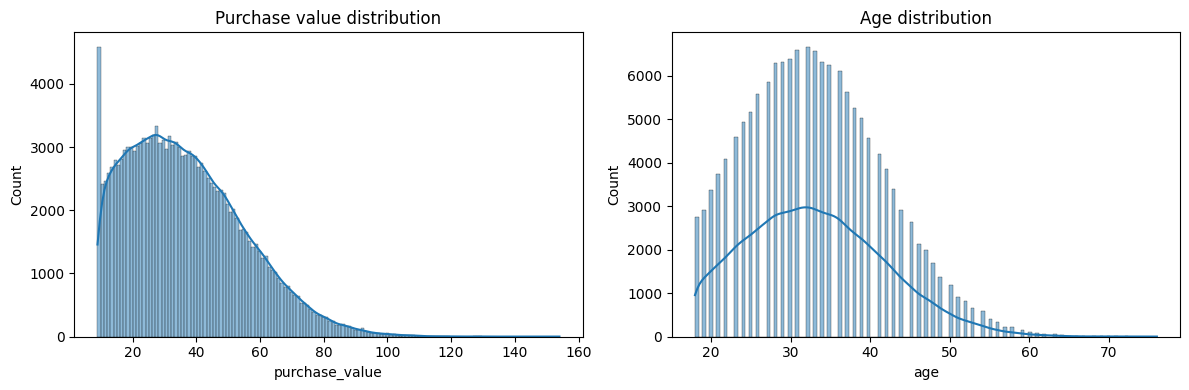

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_fraud["purchase_value"], kde=True, ax=axes[0])
axes[0].set_title("Purchase value distribution")

sns.histplot(df_fraud["age"], kde=True, ax=axes[1])
axes[1].set_title("Age distribution")

plt.tight_layout()
plt.show()


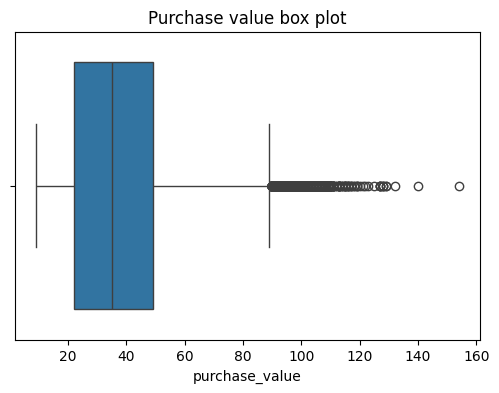

In [57]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_fraud["purchase_value"])
plt.title("Purchase value box plot")
plt.show()


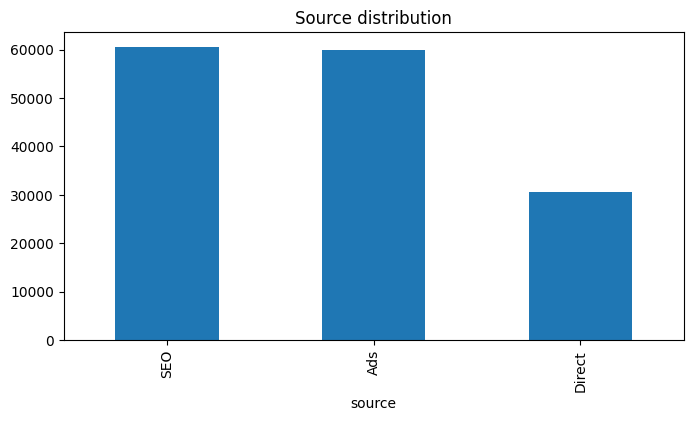

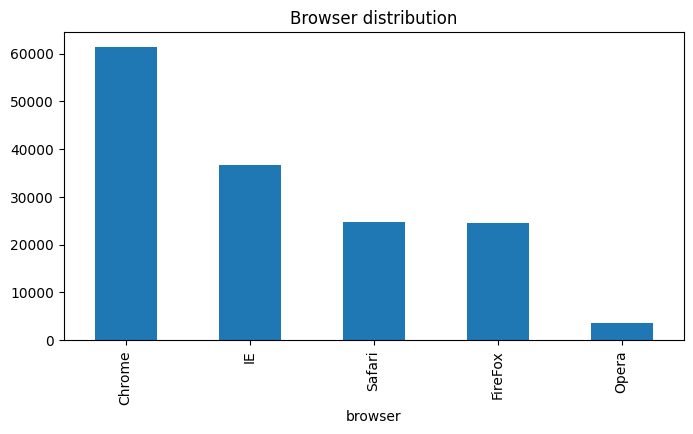

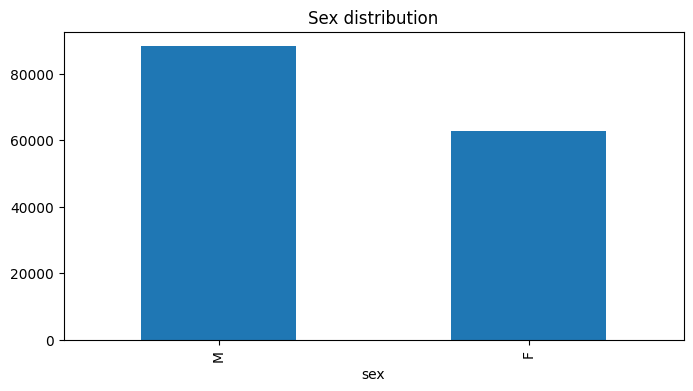

In [58]:
plt.figure(figsize=(8, 4))
df_fraud["source"].value_counts().plot(kind="bar")
plt.title("Source distribution")
plt.show()

plt.figure(figsize=(8, 4))
df_fraud["browser"].value_counts().plot(kind="bar")
plt.title("Browser distribution")
plt.show()

plt.figure(figsize=(8, 4))
df_fraud["sex"].value_counts().plot(kind="bar")
plt.title("Sex distribution")
plt.show()


class
0    136961
1     14151
Name: count, dtype: int64
Class ratio: class
0    0.906354
1    0.093646
Name: count, dtype: float64


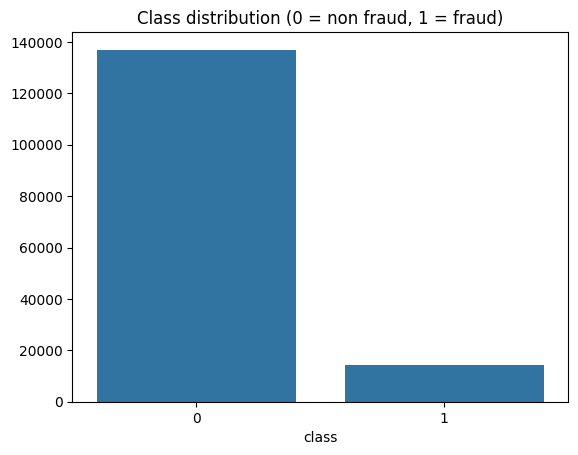

In [59]:
class_counts = df_fraud["class"].value_counts()
print(class_counts)
print("Class ratio:", class_counts / len(df_fraud))

sns.barplot(x=class_counts.index.astype(str), y=class_counts.values)
plt.title("Class distribution (0 = non fraud, 1 = fraud)")
plt.show()


Geolocation integration (IP to country)

In [95]:
def ip_to_int(ip_str):
    try:
        return int(ipaddress.ip_address(ip_str))
    except ValueError:
        return np.nan

df_fraud["ip_int"] = df_fraud["ip_address"].astype(str).apply(ip_to_int)
df_fraud["ip_int"].isna().sum()


np.int64(129146)

In [60]:
def ip_to_int(ip):
    # Robust IPv4-only conversion: dotted strings or numeric strings/floats
    if pd.isna(ip):
        return np.nan
    s = str(ip).strip()
    if not s:
        return np.nan
    # Try dotted form first
    try:
        addr = ipaddress.ip_address(s)
        if isinstance(addr, ipaddress.IPv4Address):
            return int(addr)
        else:
            # Ignore IPv6 for this dataset/bounds
            return np.nan
    except ValueError:
        pass
    # Fallback: numeric string/float (e.g., "732758368.79972")
    try:
        val = int(float(s))
        if 0 <= val <= 4294967295:
            return val
        return np.nan
    except (ValueError, OverflowError):
        return np.nan

# Apply conversion
df_fraud["ip_int"] = df_fraud["ip_address"].apply(ip_to_int)
# Quick check of invalid conversions
df_fraud["ip_int"].isna().sum()

np.int64(0)

The mapping file already has integer bounds:

lower_bound_ip_address

upper_bound_ip_address

In [62]:
def ip_to_int(ip):
    # Robust IPv4-only conversion: dotted strings or numeric strings/floats
    if pd.isna(ip):
        return np.nan
    s = str(ip).strip()
    if not s:
        return np.nan
    # Try dotted form first
    try:
        addr = ipaddress.ip_address(s)
        if isinstance(addr, ipaddress.IPv4Address):
            return int(addr)
        else:
            return np.nan
    except ValueError:
        pass
    # Fallback: numeric string/float
    try:
        val = int(float(s))
        if 0 <= val <= 4294967295:
            return val
        return np.nan
    except (ValueError, OverflowError):
        return np.nan

In [63]:
df_fraud

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,732758368
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,350311387
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,2621473820
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,3840542443
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,415583117
...,...,...,...,...,...,...,...,...,...,...,...,...
151107,345170,2015-01-27 03:03:34,2015-03-29 00:30:47,43,XPSKTWGPWINLR,SEO,Chrome,M,28,3.451155e+09,1,3451154526
151108,274471,2015-05-15 17:43:29,2015-05-26 12:24:39,35,LYSFABUCPCGBA,SEO,Safari,M,32,2.439047e+09,0,2439047221
151109,368416,2015-03-03 23:07:31,2015-05-20 07:07:47,40,MEQHCSJUBRBFE,SEO,IE,F,26,2.748471e+09,0,2748470523
151110,207709,2015-07-09 20:06:07,2015-09-07 09:34:46,46,CMCXFGRHYSTVJ,SEO,Chrome,M,37,3.601175e+09,0,3601174708


In [64]:
df_ip

,lower_bound_ip_address,upper_bound_ip_address,country
0,1.677722e+07,16777471,Australia
1,1.677747e+07,16777727,China
2,1.677773e+07,16778239,China
3,1.677824e+07,16779263,Australia
4,1.677926e+07,16781311,China
...,...,...,...
138841,3.758092e+09,3758093311,Hong Kong
138842,3.758093e+09,3758094335,India
138843,3.758095e+09,3758095871,China
138844,3.758096e+09,3758096127,Singapore


In [65]:
df_fraud_sorted = df_fraud.sort_values("ip_int").reset_index(drop=True)
df_ip_sorted = df_ip.sort_values("lower_bound_ip_address").reset_index(drop=True)


In [66]:
print(df_fraud["ip_int"].dtype)
print(df_ip["lower_bound_ip_address"].dtype)


int64
float64


In [96]:
df_ip.dtypes


lower_bound_ip_address    float64
upper_bound_ip_address    float64
country                    object
dtype: object

In [67]:
df_ip.columns

Index(['lower_bound_ip_address', 'upper_bound_ip_address', 'country'], dtype='object')

df_fraud ip_int dtype: float64
df_ip lower_bound_ip_address dtype: float64
ip_int monotonic: True
lower_bound_ip_address monotonic: True

Sample with ip_country mapped:
       ip_address      ip_int ip_country
634  1.677886e+07  16778864.0  Australia
635  1.684205e+07  16842045.0   Thailand
636  1.684366e+07  16843656.0      China
637  1.693873e+07  16938732.0      China
638  1.697198e+07  16971984.0   Thailand

Top countries by fraud rate:
                       num_tx  fraud_rate
ip_country                               
Turkmenistan                1    1.000000
Namibia                    23    0.434783
Sri Lanka                  31    0.419355
Luxembourg                 72    0.388889
Virgin Islands (U.S.)       3    0.333333
Ecuador                   106    0.264151
Tunisia                   118    0.262712
Peru                      119    0.260504
Bolivia                    53    0.245283
Kuwait                     90    0.233333
Ireland                   240    0.229167
New Zeala

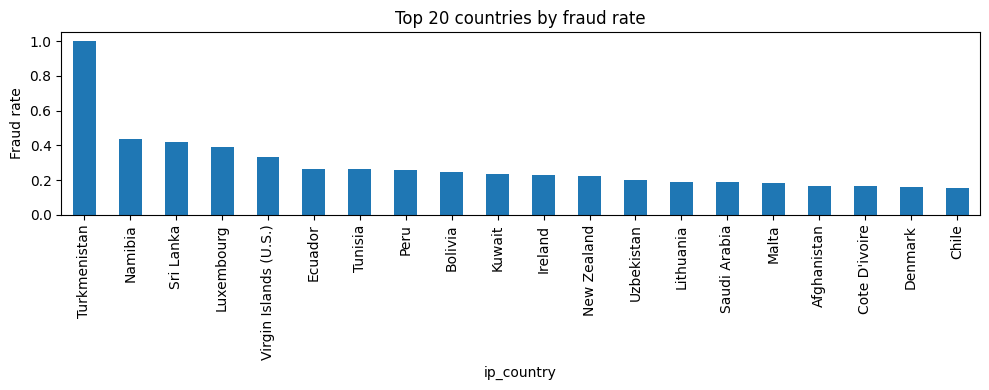

In [68]:
# -------------------------------------------------------------------
# 2. Helper to convert dotted IP to integer
# -------------------------------------------------------------------
def ip_to_int(ip):
    """Convert IPv4 to integer. Accept dotted strings or numeric strings/floats.
    Returns NaN for invalid/IPv6/out-of-range values.
    """
    if pd.isna(ip):
        return np.nan
    s = str(ip).strip()
    if not s:
        return np.nan
    # Try dotted IPv4 first
    try:
        addr = ipaddress.ip_address(s)
        if isinstance(addr, ipaddress.IPv4Address):
            return int(addr)
        else:
            return np.nan
    except ValueError:
        pass
    # Fallback: numeric string/float to int
    try:
        val = int(float(s))
        if 0 <= val <= 4294967295:
            return val
        return np.nan
    except (ValueError, OverflowError):
        return np.nan

# -------------------------------------------------------------------
# 3. Convert ip_address to numeric and clean
# -------------------------------------------------------------------
df_fraud = df_fraud.copy()
df_ip = df_ip.copy()

# Convert ip_address in Fraud_Data
df_fraud["ip_int"] = df_fraud["ip_address"].apply(ip_to_int)

# Drop rows where conversion failed (optional, but avoids NaNs)
df_fraud = df_fraud.dropna(subset=["ip_int"]).copy()

# Ensure ip_int is numeric float64
df_fraud["ip_int"] = pd.to_numeric(df_fraud["ip_int"], errors="raise").astype("float64")

# Ensure lower and upper bounds are numeric float64 too
df_ip["lower_bound_ip_address"] = pd.to_numeric(
    df_ip["lower_bound_ip_address"], errors="raise"
).astype("float64")

df_ip["upper_bound_ip_address"] = pd.to_numeric(
    df_ip["upper_bound_ip_address"], errors="raise"
).astype("float64")

# Quick dtype check
print("df_fraud ip_int dtype:", df_fraud["ip_int"].dtype)
print("df_ip lower_bound_ip_address dtype:", df_ip["lower_bound_ip_address"].dtype)

# -------------------------------------------------------------------
# 4. Sort both DataFrames on the merge key
# -------------------------------------------------------------------
df_fraud_sorted = df_fraud.sort_values("ip_int").reset_index(drop=True)
df_ip_sorted = df_ip.sort_values("lower_bound_ip_address").reset_index(drop=True)

print("ip_int monotonic:", df_fraud_sorted["ip_int"].is_monotonic_increasing)
print(
    "lower_bound_ip_address monotonic:",
    df_ip_sorted["lower_bound_ip_address"].is_monotonic_increasing,
)

# -------------------------------------------------------------------
# 5. Range merge using merge_asof
# -------------------------------------------------------------------
merged = pd.merge_asof(
    df_fraud_sorted,
    df_ip_sorted,
    left_on="ip_int",
    right_on="lower_bound_ip_address",
    direction="backward",
    allow_exact_matches=True,
)

# Keep only rows where ip_int is also <= upper bound
merged = merged[merged["ip_int"] <= merged["upper_bound_ip_address"]].copy()

# Rename country column for clarity
merged = merged.rename(columns={"country": "ip_country"})

# Final result
df_fraud = merged

print("\nSample with ip_country mapped:")
print(df_fraud[["ip_address", "ip_int", "ip_country"]].head())

# -------------------------------------------------------------------
# 6. Fraud rate by country (for EDA and report)
# -------------------------------------------------------------------
fraud_by_country = (
    df_fraud.groupby("ip_country")["class"]
    .agg(["count", "mean"])
    .rename(columns={"count": "num_tx", "mean": "fraud_rate"})
    .sort_values("fraud_rate", ascending=False)
)

print("\nTop countries by fraud rate:")
print(fraud_by_country.head(20))

# Optional: plot top 20 by fraud rate
top_countries = fraud_by_country.head(20)
plt.figure(figsize=(10, 4))
top_countries["fraud_rate"].plot(kind="bar")
plt.ylabel("Fraud rate")
plt.title("Top 20 countries by fraud rate")
plt.tight_layout()
plt.show()

Fraud by country

Plot

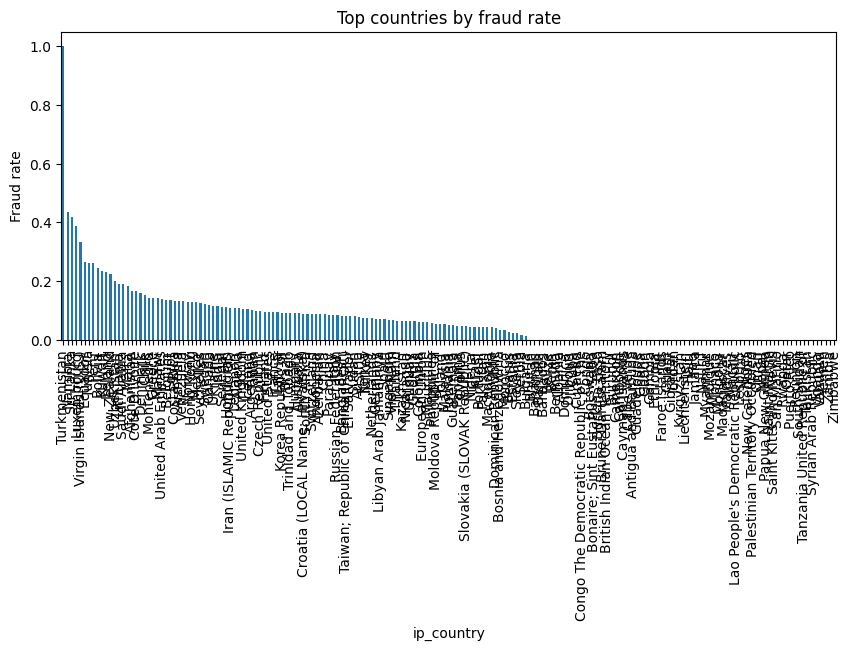

In [69]:
fraud_by_country["fraud_rate"].plot(kind="bar", figsize=(10, 4))
plt.title("Top countries by fraud rate")
plt.ylabel("Fraud rate")
plt.show()


Feature engineering for Fraud_Data

In [75]:
df_fraud["hour_of_day"] = df_fraud["purchase_time"].dt.hour
df_fraud["day_of_week"] = df_fraud["purchase_time"].dt.dayofweek  # Monday = 0
df_fraud["time_since_signup_hours"] = (
    df_fraud["purchase_time"] - df_fraud["signup_time"]
).dt.total_seconds() / 3600.0


Sort and group by user and time

In [90]:
# Make sure purchase_time is datetime
df_fraud["purchase_time"] = pd.to_datetime(df_fraud["purchase_time"], errors="coerce")

# Sort and reset index to avoid index alignment issues
df_fraud = df_fraud.sort_values(["user_id", "purchase_time"]).reset_index(drop=True)

# Total transactions per user
df_fraud["user_tx_count_total"] = (
    df_fraud.groupby("user_id")["purchase_time"].transform("count")
)

# Group object to reuse
grp = df_fraud.groupby("user_id")

# Rolling counts in the last 24 hours (1D) per user
tx_24h = (
    grp.rolling("1D", on="purchase_time")["purchase_time"]
    .count()
    .reset_index(level=0, drop=True)  # drop user_id level
    .sub(1)  # exclude current transaction
)

# Rolling counts in the last 7 days per user
tx_7d = (
    grp.rolling("7D", on="purchase_time")["purchase_time"]
    .count()
    .reset_index(level=0, drop=True)
    .sub(1)
)

# Assign using .values to avoid reindexing issues with duplicate labels
df_fraud["tx_count_24h"] = tx_24h.values
df_fraud["tx_count_7d"] = tx_7d.values

df_fraud[["user_id", "purchase_time", "tx_count_24h", "tx_count_7d"]].head()


,user_id,purchase_time,tx_count_24h,tx_count_7d
0,2,2015-02-21 10:03:37,0.0,0.0
1,4,2015-09-26 21:32:16,0.0,0.0
2,8,2015-08-13 11:53:07,0.0,0.0
3,12,2015-03-04 20:56:37,0.0,0.0
4,16,2015-03-12 12:46:23,0.0,0.0


Data transformation (scaling + encoding)

In [97]:
target_col = "class"

num_cols = [
    "purchase_value",
    "age",
    "time_since_signup_hours",
    "user_tx_count_total",
    "tx_count_24h",
    "tx_count_7d",
]

cat_cols = [
    "source",
    "browser",
    "sex",
    "ip_country",
]


Build a preprocessing pipeline

In [98]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)


In [99]:
X = df_fraud[num_cols + cat_cols]
y = df_fraud[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Handling class imbalance for Fraud_Data

In [93]:
# SMOTE instance
smote = SMOTE(random_state=42)

# Optional: if you want to look at numeric and categorical parts separately
X_train_num = X_train[num_cols].copy()
X_train_cat = X_train[cat_cols].copy()

# Fit the preprocessor on training data and transform train and test
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

# Class distribution before SMOTE
print("Before SMOTE:", np.bincount(y_train.astype(int)))

# Apply SMOTE on the transformed training data only
X_resampled, y_resampled = smote.fit_resample(X_train_prepared, y_train.astype(int))

# Class distribution after SMOTE
print("After SMOTE:", np.bincount(y_resampled))


Before SMOTE: [93502  9814]
After SMOTE: [93502 93502]


In [70]:
# Optional: save the cleaned and feature engineered fraud data
df_fraud.to_csv("../data/processed/fraud_features.csv", index=False)


creditcard.csv: cleaning, EDA, scaling, imbalance

In [71]:
credit_path = "../data/raw/creditcard.csv"
df_cc = pd.read_csv(credit_path)
df_cc.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Cleaning

In [72]:
df_cc.isna().sum()        # usually zero
df_cc.duplicated().sum()  # drop if any

df_cc = df_cc.drop_duplicates()


EDA: summary stats, distributions, imbalance

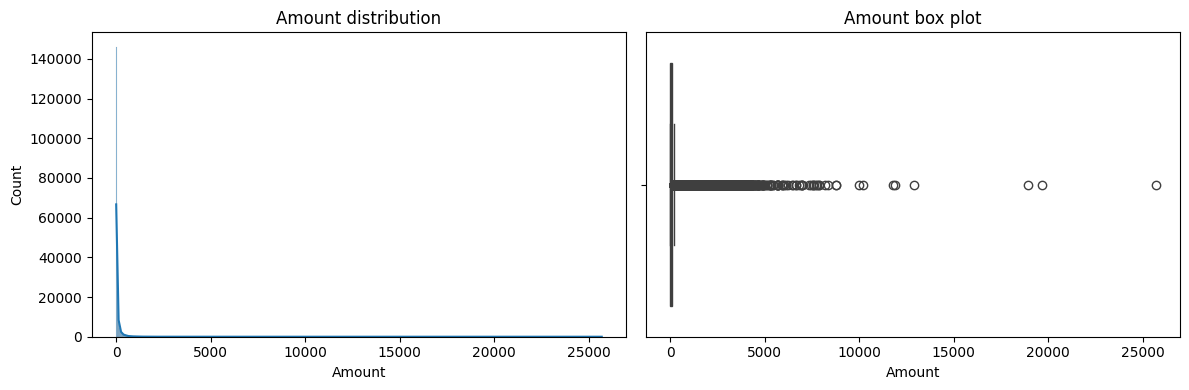

In [73]:
df_cc[["Amount", "Time"]].describe().T
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_cc["Amount"], kde=True, ax=axes[0])
axes[0].set_title("Amount distribution")
sns.boxplot(x=df_cc["Amount"], ax=axes[1])
axes[1].set_title("Amount box plot")
plt.tight_layout()
plt.show()


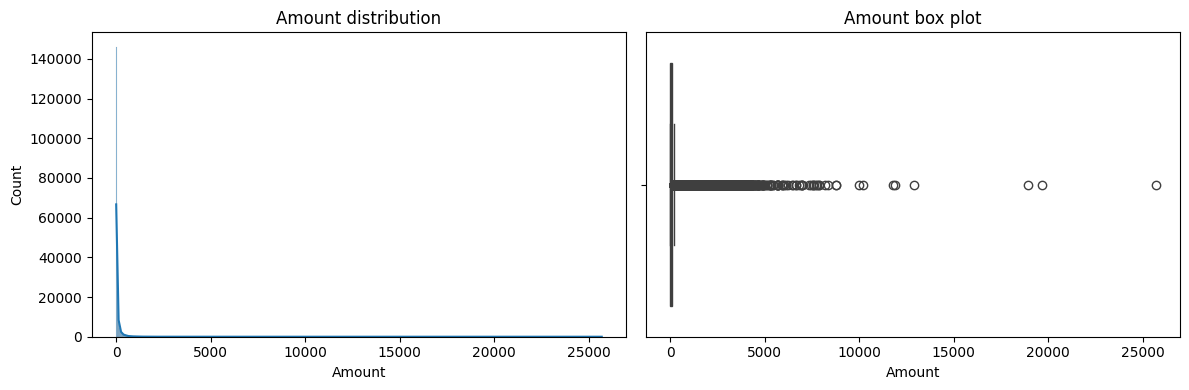

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_cc["Amount"], kde=True, ax=axes[0])
axes[0].set_title("Amount distribution")
sns.boxplot(x=df_cc["Amount"], ax=axes[1])
axes[1].set_title("Amount box plot")
plt.tight_layout()
plt.show()


Class
0    283253
1       473
Name: count, dtype: int64
Class
0    0.998333
1    0.001667
Name: count, dtype: float64


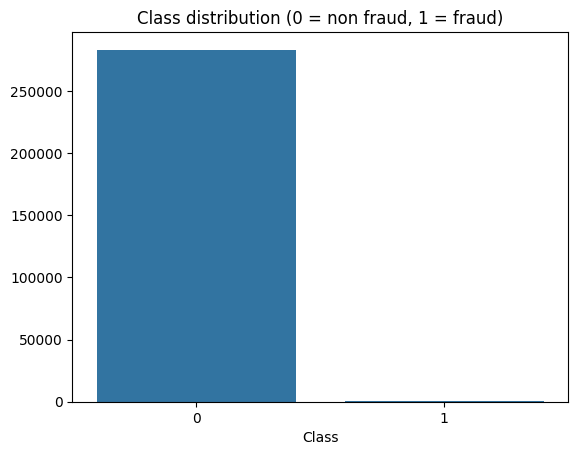

In [85]:
cc_counts = df_cc["Class"].value_counts()
print(cc_counts)
print(cc_counts / len(df_cc))

sns.barplot(x=cc_counts.index.astype(str), y=cc_counts.values)
plt.title("Class distribution (0 = non fraud, 1 = fraud)")
plt.show()


Feature prep for creditcard

In [94]:
feature_cols = [c for c in df_cc.columns if c != "Class"]
target_col_cc = "Class"

X_cc = df_cc[feature_cols]
y_cc = df_cc[target_col_cc]

X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc, y_cc, test_size=0.2, stratify=y_cc, random_state=42
)

scaler_cc = StandardScaler()
X_train_cc_scaled = scaler_cc.fit_transform(X_train_cc)
X_test_cc_scaled = scaler_cc.transform(X_test_cc)

print("Before SMOTE:", np.bincount(y_train_cc))
smote_cc = SMOTE(random_state=42)
X_train_cc_res, y_train_cc_res = smote_cc.fit_resample(X_train_cc_scaled, y_train_cc)
print("After SMOTE:", np.bincount(y_train_cc_res))


Before SMOTE: [226602    378]
After SMOTE: [226602 226602]
